# Checking for improvability of peft intruders efficiency

----------------------------------------
Ressources used in this Colab:


*   15GB GPU-RAM - T4
*   12.7 GB System-RAM
*   112 GB Laufwerk

----------------------------------------

Repo with already fine-tuned parameters and requirements


In [ ]:
!git clone https://github.com/causeri3/emo-llava

Cloning into 'emo-llava'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 51 (delta 8), reused 12 (delta 4), pack-reused 33 (from 1)
Receiving objects: 100% (51/51), 104.86 MiB | 23.49 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (26/26), done.


In [ ]:
!cp -r emo-llava/* .

In [ ]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/peft.git (to revision main) to /tmp/pip-install-2skn5jc0/peft_07275cb995ad4252805b38b7b58f3bab
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft.git /tmp/pip-install-2skn5jc0/peft_07275cb995ad4252805b38b7b58f3bab
  Resolved https://github.com/huggingface/peft.git to commit 76c37d4686cf7245a9a6998fd1e2619d62c9322d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.8 MB/s eta 0:00:00
  Created wheel for peft: filename=peft-0.19.2.dev0-py3-none-any.whl size=678266 sha256=ffd52f57a72ee58a249a0d1832bbc1cb4398ef5e0f3710e769549e88a07fa4b9
  Stored in directory: /tmp/pip-ephem-wheel-cache-da1vs7ip/wheels/06/69/8a/12bda986134091860052732ecf5b5e478eb9b6fc404be4d53f
Successfully built peft
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Unin

Download Base Model


In [ ]:
!yes n | hf download llava-hf/llava-1.5-7b-hf --local-dir llava-1.5-7b-hf

A new version of huggingface_hub (1.11.0) is available! You are using version 1.10.1.
To update, run: /usr/bin/python3 -m pip install -U huggingface_hub

Fetching 17 files:   0% 0/17 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 17 files: 100% 17/17 [04:52<00:00, 17.18s/it]
Download complete: : 14.1GB [04:52, 88.8MB/s]              /content/llava-1.5-7b-hf
Download complete: : 14.1GB [04:52, 48.4MB/s]


Run via CPU

In [ ]:
from peft import PeftModel
from transformers import LlavaForConditionalGeneration
from transformers.trainer_utils import get_last_checkpoint
from peft.tuners.lora.intruders import reduce_intruder_dimension
import torch
import os
import json

last_checkpoint = get_last_checkpoint("llava-emotion-lora")
logs_path = os.path.join(last_checkpoint, "trainer_state.json")
with open(logs_path, "r") as f:
    check_data = json.load(f)
log_history = check_data["log_history"]

#device = torch.device("cuda")

base_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)#.to(device)

tuned_model = PeftModel.from_pretrained(base_model, check_data["best_model_checkpoint"])


# subset of layers because colab ran out of RAM
original_named_modules = tuned_model.named_modules
counter = 0
max_layers = 500

def limited_named_modules():
    global counter
    for name, module in original_named_modules():
        yield name, module
        counter += 1
        if counter >= max_layers:
            return

tuned_model.named_modules = limited_named_modules

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
    ],
    record_shapes=True,
    with_stack=False
) as prof:
    reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 2
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

In [ ]:
from IPython.display import display, Markdown

table = prof.key_averages().table(sort_by="cpu_time_total")
display(Markdown(f"```\n{table}\n```"))

```
-------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                           aten::linalg_svd         0.00%     499.892us        95.66%       29.528s     447.398ms            66  
                          aten::_linalg_svd        94.92%       29.300s        95.65%       29.528s     447.390ms            66  
                               aten::matmul         0.00%       1.284ms         2.59%     799.287ms       6.552ms           122  
                                   aten::mm         2.58%     797.866ms         2.59%     798.003ms       6.541ms           122  
                                aten::copy_         1.10%     338.722ms         1.10%     338.857ms     388.597us           872  
                                aten::clone         0.01%       2.657ms         0.71%     220.277ms       2.448ms            90  
                                   aten::to         0.01%       2.457ms         0.44%     136.787ms     191.043us           716  
                             aten::_to_copy         0.03%       8.592ms         0.44%     134.330ms     203.530us           660  
                                  aten::add         0.29%      89.063ms         0.42%     129.599ms       3.240ms            40  
                             aten::uniform_         0.28%      85.613ms         0.28%      85.613ms     254.800us           336  
                                  aten::mul         0.21%      64.103ms         0.21%      65.145ms       1.629ms            40  
                                  aten::max         0.19%      59.631ms         0.20%      60.483ms       2.326ms            26  
                                 aten::diag         0.00%     213.194us         0.11%      34.324ms     612.931us            56  
                           aten::diag_embed         0.00%     844.016us         0.11%      34.111ms     609.124us            56  
                                  aten::abs         0.06%      17.210ms         0.11%      33.852ms     650.992us            52  
                                aten::zero_         0.00%       1.137ms         0.11%      33.438ms     142.896us           234  
                                  aten::sub         0.11%      33.215ms         0.11%      33.215ms       2.373ms            14  
                                aten::zeros         0.00%     978.141us         0.11%      33.038ms     270.803us           122  
                                aten::fill_         0.10%      32.300ms         0.10%      32.300ms     351.092us            92  
                 aten::_linalg_check_errors         0.00%     817.267us         0.02%       7.128ms     107.994us            66  
                                  aten::any         0.01%       1.672ms         0.02%       5.926ms      89.781us            66  
                                aten::empty         0.02%       4.784ms         0.02%       4.784ms       8.163us           586  
                        aten::empty_strided         0.02%       4.742ms         0.02%       4.742ms       6.933us           684  
                                 aten::div_         0.01%       3.946ms         0.01%       4.288ms     306.267us            14  
                                 aten::sqrt         0.01%       3.767ms         0.01%       3.767ms      67.260us            56  
                                aten::index         0.01%       1.747ms         0.01%       2.148ms      38.361us            56  
                               aten::detach         0.00%     787.489us         0.01%       1.691ms       7.550us           224  
                                   aten::lt         0.00%     577.437us         0.00%       1.221ms      46.979us            26  
                                aten::slice         0.00%       1.028ms         0.00%       1.216ms      14.829us            82  
                              aten::view_as         0.00%     800.879us         0.00%       1.196ms      18.122us            66  
                                aten::where         0.00%      80.936us         0.00%       1.093ms      42.023us            26  
                        aten::nonzero_numpy         0.00%     143.200us         0.00%       1.012ms      38.910us            26  
                           aten::transpose_         0.00%     600.337us         0.00%     992.077us      15.031us            66  
                                   aten::mT         0.00%     283.407us         0.00%     960.695us      14.556us            66  
                                     detach         0.00%     903.646us         0.00%     903.646us       4.034us           224  
                           aten::as_strided         0.00%     734.893us         0.00%     734.893us       2.355us           312  
                          aten::as_strided_         0.00%     698.551us         0.00%     698.551us       3.564us           196  
                              aten::numpy_T         0.00%     170.193us         0.00%     682.353us      26.244us            26  
                            aten::transpose         0.00%     453.331us         0.00%     677.288us      10.262us            66  
                           aten::empty_like         0.00%     255.147us         0.00%     612.081us       9.274us            66  
    aten::_has_compatible_shallow_copy_type         0.00%     603.053us         0.00%     603.053us       0.833us           724  
                                 aten::view         0.00%     531.410us         0.00%     531.410us       4.356us           122  
                           aten::unsqueeze_         0.00%     318.507us         0.00%     517.399us       9.950us            52  
                              aten::permute         0.00%     424.525us         0.00%     512.160us      19.698us            26  
                              aten::nonzero         0.00%     403.505us         0.00%     475.143us      18.275us            26  
                             aten::diagonal         0.00%     299.759us         0.00%     402.617us       7.190us            56  
                               aten::unbind         0.00%     208.447us         0.00%     393.326us      15.128us            26  
                                 aten::item         0.00%     263.472us         0.00%     384.803us       5.830us            66  
                             aten::squeeze_         0.00%     257.773us         0.00%     334.367us       6.430us            52  
                              aten::reshape         0.00%     159.376us         0.00%     295.601us       5.279us            56  
                               aten::select         0.00%     157.923us         0.00%     184.879us       7.111us            26  
                         aten::resolve_conj         0.00%     158.300us         0.00%     158.300us       0.468us           338  
                  aten::_local_scalar_dense         0.00%     121.331us         0.00%     121.331us       1.838us            66  
                           aten::lift_fresh         0.00%      44.991us         0.00%      44.991us       0.803us            56  
                          aten::resolve_neg         0.00%       6.404us         0.00%       6.404us       0.246us            26  
-------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 30.869s

```

Restart kernel

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

Run via GPU

In [ ]:
from peft import PeftModel
from transformers import LlavaForConditionalGeneration
from transformers.trainer_utils import get_last_checkpoint
from peft.tuners.lora.intruders import reduce_intruder_dimension
import torch
import os
import json

last_checkpoint = get_last_checkpoint("llava-emotion-lora")
logs_path = os.path.join(last_checkpoint, "trainer_state.json")
with open(logs_path, "r") as f:
    check_data = json.load(f)
log_history = check_data["log_history"]

device = torch.device("cuda")

base_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(device)

tuned_model = PeftModel.from_pretrained(base_model, check_data["best_model_checkpoint"])


# subset of layers because colab ran out of RAM
original_named_modules = tuned_model.named_modules
counter = 0
max_layers = 500

def limited_named_modules():
    global counter
    for name, module in original_named_modules():
        yield name, module
        counter += 1
        if counter >= max_layers:
            return

tuned_model.named_modules = limited_named_modules

# warm up run (to get rid of module/kernel loading overhead)
with torch.no_grad():
    counter = 0
    reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)

torch.cuda.synchronize()

# actual profiling run
counter = 0

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CUDA,
        torch.profiler.ProfilerActivity.CPU,
    ],
    record_shapes=True,
    with_stack=False
) as prof:
    torch.cuda.synchronize()
    reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)
    torch.cuda.synchronize()


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 2
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 2
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

In [ ]:
from IPython.display import display, Markdown

table = prof.key_averages().table(sort_by="cuda_time_total")
display(Markdown(f"```\n{table}\n```"))

```
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       aten::linalg_svd         0.00%     310.763us        98.76%       14.505s     219.776ms       0.000us         0.00%       24.196s     366.601ms            66  
                                      aten::_linalg_svd         1.79%     262.680ms        98.76%       14.505s     219.772ms       13.767s        99.75%       24.196s     366.601ms            66  
                                           Buffer Flush         0.32%      46.312ms         0.32%      46.360ms       1.656ms        7.053s        51.10%        7.053s     251.883ms            28  
void svd_column_rotate_batch<float, 5, 3>(long, int ...         0.00%       0.000us         0.00%       0.000us       0.000us        6.942s        50.30%        6.942s      49.370us        140616  
void gesvdbj_batch_32x16<float, float>(long, int con...         0.00%       0.000us         0.00%       0.000us       0.000us        3.738s        27.08%        3.738s      53.166us         70308  
                                Activity Buffer Request         0.49%      71.554ms         0.49%      71.554ms       2.862ms        3.372s        24.43%        3.372s     134.863ms            25  
void svd_row_rotate_batch_32x16<float>(long, int con...         0.00%       0.000us         0.00%       0.000us       0.000us        3.005s        21.77%        3.005s      42.742us         70308  
                                       cudaLaunchKernel        10.82%        1.590s        11.01%        1.617s       5.461us       0.000us         0.00%        1.386s       4.681us        296152  
                                        cudaMemcpyAsync        85.20%       12.514s        85.28%       12.525s       5.730ms       0.000us         0.00%     502.189ms     229.729us          2186  
void offA_stage1<float, float, 5, 3>(long, long, flo...         0.00%       0.000us         0.00%       0.000us       0.000us      33.150ms         0.24%      33.150ms      28.045us          1182  
                                           aten::matmul         0.00%     604.972us         0.26%      38.036ms     311.774us       0.000us         0.00%      19.143ms     156.910us           122  
                                               aten::mm         0.23%      34.137ms         0.25%      37.431ms     306.815us      19.143ms         0.14%      19.143ms     156.910us           122  
                                  volta_sgemm_128x64_tn         0.00%       0.000us         0.00%       0.000us       0.000us      12.166ms         0.09%      12.166ms     467.922us            26  
                                            aten::copy_         0.10%      14.327ms         0.36%      52.514ms      38.557us       7.652ms         0.06%       8.968ms       6.585us          1362  
void colperm_kernel<float, float, 5, 4>(long, long, ...         0.00%       0.000us         0.00%       0.000us       0.000us       6.236ms         0.05%       6.236ms      47.239us           132  
                                  volta_sgemm_128x64_nn         0.00%       0.000us         0.00%       0.000us       0.000us       5.814ms         0.04%       5.814ms     415.310us            14  
void pegasus_sortI32_by_key_local_core<256, 4, false...         0.00%       0.000us         0.00%       0.000us       0.000us       5.280ms         0.04%       5.280ms       2.581us          2046  
void pegasus_sortI32_by_key_merge_core<256, 4>(int, ...         0.00%       0.000us         0.00%       0.000us       0.000us       5.244ms         0.04%       5.244ms       2.563us          2046  
void pegasusIinclusive_scan_domino_v1_core<256, 4>(i...         0.00%       0.000us         0.00%       0.000us       0.000us       5.232ms         0.04%       5.232ms       2.477us          2112  
void pegasusIinclusive_localscan_core<256, 4>(int, i...         0.00%       0.000us         0.00%       0.000us       0.000us       4.550ms         0.03%       4.550ms       2.154us          2112  
void at::native::elementwise_kernel<128, 2, at::nati...         0.00%       0.000us         0.00%       0.000us       0.000us       3.970ms         0.03%       3.970ms      32.542us           122  
                                            aten::clone         0.02%       2.269ms         0.05%       7.588ms      84.306us       0.000us         0.00%       3.872ms      43.025us            90  
                                               aten::to         0.02%       3.107ms         0.41%      59.840ms      64.622us       0.000us         0.00%       3.534ms       3.817us           926  
                                         aten::_to_copy         0.06%       8.345ms         0.39%      56.732ms      61.266us       0.000us         0.00%       3.534ms       3.817us           926  
void pegasusIinclusive_scan_merge_core<256, 4>(int, ...         0.00%       0.000us         0.00%       0.000us       0.000us       3.449ms         0.02%       3.449ms       1.633us          2112  
                                        Memset (Device)         0.00%       0.000us         0.00%       0.000us       0.000us       2.839ms         0.02%       2.839ms       0.646us          4396  
void batch_eye_kernel<float, 5, 3>(long, long, float...         0.00%       0.000us         0.00%       0.000us       0.000us       2.588ms         0.02%       2.588ms      19.603us           132  
void batch_FnrmA_stage1<float, float, 8>(long, long,...         0.00%       0.000us         0.00%       0.000us       0.000us       2.575ms         0.02%       2.575ms      39.017us            66  
            void offA_stage2<float, 5, 3>(long, float*)         0.00%       0.000us         0.00%       0.000us       0.000us       2.480ms         0.02%       2.480ms       2.098us          1182  
void syevj_parallel_order_set_kernel<512>(long, int*...         0.00%       0.000us         0.00%       0.000us       0.000us       2.165ms         0.02%       2.165ms      16.400us           132  
void svd_col_scale_kernel<float, 256>(long, long, fl...         0.00%       0.000us         0.00%       0.000us       0.000us       2.052ms         0.01%       2.052ms      31.087us            66  
                                              aten::add         0.01%     768.534us         0.01%       1.205ms      30.134us       2.049ms         0.01%       2.049ms      51.233us            40  
                       Memcpy DtoH (Device -> Pageable)         0.00%       0.000us         0.00%       0.000us       0.000us       1.852ms         0.01%       1.852ms       1.329us          1394  
                                              aten::abs         0.01%     885.131us         0.02%       2.641ms      50.782us     893.596us         0.01%       1.787ms      34.369us            52  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us       1.550ms         0.01%       1.550ms       6.201us           250  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       1.494ms         0.01%       1.494ms      53.366us            28  
                                              aten::mul         0.01%       1.092ms         0.01%       1.544ms      38.597us       1.412ms         0.01%       1.412ms      35.301us            40  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       1.412ms         0.01%       1.412ms      35.301us            40  
                       Memcpy HtoD (Pageable -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us       1.344ms         0.01%       1.344ms       4.800us           280  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us       1.298ms         0.01%       1.298ms      49.938us            26  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     893.596us         0.01%     893.596us      34.369us            26  
void lascl_kernel<float, float, 8>(long, long, float...         0.00%       0.000us         0.00%       0.000us       0.000us     807.133us         0.01%     807.133us      12.229us            66  
                                  volta_sgemm_128x32_nn         0.00%       0.000us         0.00%       0.000us       0.000us     743.388us         0.01%     743.388us      19.563us            38  
                                              aten::sub         0.00%     216.519us         0.00%     332.836us      23.774us     743.326us         0.01%     743.326us      53.095us            14  
                         Memcpy DtoD (Device -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us     645.404us         0.00%     645.404us       1.537us           420  
                                             aten::diag         0.00%     197.441us         0.04%       6.247ms     111.545us       0.000us         0.00%     644.351us      11.506us            56  
                                       aten::diag_embed         0.00%     664.860us         0.04%       6.049ms     108.019us       0.000us         0.00%     644.351us      11.506us            56  
                                            aten::zero_         0.01%     984.220us         0.03%       4.306ms      18.401us       0.000us         0.00%     613.759us       2.623us           234  
                                            aten::fill_         0.01%       1.833ms         0.02%       3.322ms      17.859us     613.759us         0.00%     613.759us       3.300us           186  
                                            aten::zeros         0.01%       1.567ms         0.08%      12.038ms      98.670us       0.000us         0.00%     613.759us       5.031us           122  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     499.103us         0.00%     499.103us       8.913us            56  
                                              aten::max         0.01%       1.456ms         0.01%       1.840ms      70.755us     481.470us         0.00%     481.470us      18.518us            26  
void at::native::reduce_kernel<512, 1, at::native::R...         0.00%       0.000us         0.00%       0.000us       0.000us     481.470us         0.00%     481.470us      18.518us            26  
                                             aten::div_         0.00%     260.258us         0.00%     403.609us      28.829us     424.287us         0.00%     424.287us      30.306us            14  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     424.287us         0.00%     424.287us      30.306us            14  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     372.512us         0.00%     372.512us      26.608us            14  
                             aten::_linalg_check_errors         0.01%       1.026ms         0.07%      10.275ms     155.682us       0.000us         0.00%     350.977us       5.318us            66  
                                            aten::index         0.01%       1.825ms         0.03%       5.064ms      90.422us     324.895us         0.00%     324.895us       5.802us            56  
void gemmk1_kernel<int, float, 256, 5, false, false,...         0.00%       0.000us         0.00%       0.000us       0.000us     303.232us         0.00%     303.232us      18.952us            16  
void at::native::index_elementwise_kernel<128, 4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     296.095us         0.00%     296.095us       6.729us            44  
void batch_FnrmA_stage2<float, 8>(long, float*, long...         0.00%       0.000us         0.00%       0.000us       0.000us     294.080us         0.00%     294.080us       4.456us            66  
                                              aten::any         0.01%       1.917ms         0.05%       7.006ms     106.159us       0.000us         0.00%     261.057us       3.955us            66  
void pegasus_sortsign_by_key_local_core<float, 256, ...         0.00%       0.000us         0.00%       0.000us       0.000us     217.279us         0.00%     217.279us       3.292us            66  
                                            aten::where         0.00%     100.348us         0.12%      17.921ms     689.288us       0.000us         0.00%     202.590us       7.792us            26  
                                    aten::nonzero_numpy         0.00%     505.458us         0.12%      17.821ms     685.428us       0.000us         0.00%     202.590us       7.792us            26  
                                          aten::nonzero         0.05%       7.711ms         0.11%      16.890ms     649.626us     202.590us         0.00%     202.590us       7.792us            26  
void pegasus_sortsign_by_key_merge_core<float, 256, ...         0.00%       0.000us         0.00%       0.000us       0.000us     168.544us         0.00%     168.544us       2.554us            66  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us     160.769us         0.00%     160.769us       2.436us            66  
void scal_kernel_val<float, float>(cublasScalParamsV...         0.00%       0.000us         0.00%       0.000us       0.000us     157.440us         0.00%     157.440us       2.385us            66  
void gesvdj_diagonal_kernel<float, float, 256>(long,...         0.00%       0.000us         0.00%       0.000us       0.000us     141.376us         0.00%     141.376us       2.142us            66  
                         Memcpy DtoH (Device -> Pinned)         0.00%       0.000us         0.00%       0.000us       0.000us     125.375us         0.00%     125.375us       1.363us            92  
                                             aten::sqrt         0.01%     926.366us         0.01%       1.468ms      26.217us     123.615us         0.00%     123.615us       2.207us            56  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     123.615us         0.00%     123.615us       2.207us            56  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     114.656us         0.00%     114.656us       1.737us            66  
                            copy_info_kernel(int, int*)         0.00%       0.000us         0.00%       0.000us       0.000us     113.248us         0.00%     113.248us       1.716us            66  
                void pegasus_set_identy<128>(int, int*)         0.00%       0.000us         0.00%       0.000us       0.000us      97.344us         0.00%      97.344us       1.475us            66  
                                             aten::item         0.00%     275.738us         0.02%       2.243ms      33.983us       0.000us         0.00%      89.920us       1.362us            66  
                              aten::_local_scalar_dense         0.01%       1.010ms         0.01%       1.967ms      29.805us      89.920us         0.00%      89.920us       1.362us            66  
                                               aten::lt         0.01%     770.787us         0.01%       1.092ms      42.009us      72.447us         0.00%      72.447us       2.786us            26  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us      72.447us         0.00%      72.447us       2.786us            26  
void at_cuda_detail::cub::DeviceSelectSweepKernel<at...         0.00%       0.000us         0.00%       0.000us       0.000us      66.559us         0.00%      66.559us       2.560us            26  
void at_cuda_detail::cub::DeviceReduceSingleTileKern...         0.00%       0.000us         0.00%       0.000us       0.000us      63.616us         0.00%      63.616us       2.447us            26  
                                  volta_sgemm_128x32_nt         0.00%       0.000us         0.00%       0.000us       0.000us      54.176us         0.00%      54.176us       3.870us            14  
void gemmSN_NN_kernel<float, 128, 2, 4, 8, 4, 4, fal...         0.00%       0.000us         0.00%       0.000us       0.000us      40.640us         0.00%      40.640us       2.903us            14  
void at_cuda_detail::cub::DeviceCompactInitKernel<at...         0.00%       0.000us         0.00%       0.000us       0.000us      36.960us         0.00%      36.960us       1.422us            26  
void at::native::vectorized_gather_kernel<16, long>(...         0.00%       0.000us         0.00%       0.000us       0.000us      28.800us         0.00%      28.800us       2.400us            12  
                                  cudaDeviceSynchronize         0.00%      68.657us         0.00%      68.657us      22.886us       0.000us         0.00%       0.000us       0.000us             3  
                                            aten::empty         0.07%      10.049ms         0.07%      10.049ms      20.342us       0.000us         0.00%       0.000us       0.000us           494  
                                           aten::detach         0.00%     316.488us         0.01%     843.861us       3.767us       0.000us         0.00%       0.000us       0.000us           224  
                                                 detach         0.00%     527.373us         0.00%     527.373us       2.354us       0.000us         0.00%       0.000us       0.000us           224  
                                         aten::uniform_         0.33%      48.222ms         0.33%      48.222ms     143.517us       0.000us         0.00%       0.000us       0.000us           336  
                                    aten::empty_strided         0.09%      13.088ms         0.09%      13.863ms      14.593us       0.000us         0.00%       0.000us       0.000us           950  
                                        aten::expand_as         0.00%     462.881us         0.01%       1.357ms       6.060us       0.000us         0.00%       0.000us       0.000us           224  
                                           aten::expand         0.00%     595.919us         0.01%     894.521us       3.993us       0.000us         0.00%       0.000us       0.000us           224  
                                       aten::as_strided         0.01%       1.058ms         0.01%       1.058ms       1.555us       0.000us         0.00%       0.000us       0.000us           680  
                                  cudaStreamSynchronize         0.11%      15.688ms         0.11%      15.688ms       8.883us       0.000us         0.00%       0.000us       0.000us          1766  
                aten::_has_compatible_shallow_copy_type         0.00%     355.615us         0.00%     355.615us       0.491us       0.000us         0.00%       0.000us       0.000us           724  
                                  cudaStreamIsCapturing         0.00%       9.043us         0.00%       9.043us       1.809us       0.000us         0.00%       0.000us       0.000us             5  
                                             cudaMalloc         0.01%     765.821us         0.01%     765.821us     153.164us       0.000us         0.00%       0.000us       0.000us             5  
          cudaOccupancyMaxActiveBlocksPerMultiprocessor         0.00%     312.174us         0.00%     312.174us       4.002us       0.000us         0.00%       0.000us       0.000us            78  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 14.687s
Self CUDA time total: 13.802s

```

In [ ]:
start = torch.cuda.Event(enable_timing=True)
end_svd = torch.cuda.Event(enable_timing=True)
end_total = torch.cuda.Event(enable_timing=True)

# patch linalg_svd to measure only SVD time
original_svd = torch.linalg.svd
svd_total_ms = 0.0

def timed_svd(*args, **kwargs):
    global svd_total_ms
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    s.record()
    result = original_svd(*args, **kwargs)
    e.record()
    torch.cuda.synchronize()
    svd_total_ms += s.elapsed_time(e)
    return result

torch.linalg.svd = timed_svd


counter = 0
start.record()
reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)
end_total.record()
torch.cuda.synchronize()

torch.linalg.svd = original_svd

total_ms = start.elapsed_time(end_total)
print(f"Total GPU time:   {total_ms:.2f} ms")
print(f"SVD GPU time:     {svd_total_ms:.2f} ms")
print(f"SVD share:        {100 * svd_total_ms / total_ms:.1f}%")

base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 2
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

#lowrank SVD approach

Skim for intruders with lowrank (way fast, but leads consistenly to false positives). Once intruders are detected, double check with full SVD and use output for mitigation

----------------------------

Performance measured on my Mac.
(It takes way too long in this notebook.)

With Fine-tuned LLaVa (from repo).

Baseline is current full svd code with all default settings.

---------------

*  **Compute**: M3, 36GB Memory
*  **Base Model**: llava-1.5-7b-hf
* **Default args**:
    top_k=10,
    threshold_epsilon=0.5,
    mitigation_lambda=0.75
* **lowrank args**:
    q=top_k,
    niter=320

*  **LoRA layers**:

    8 layers: 1024 ×  1024, rank 8

   64 layers: 4096 ×  4096, rank 8



------------

In [1]:
%matplotlib inline

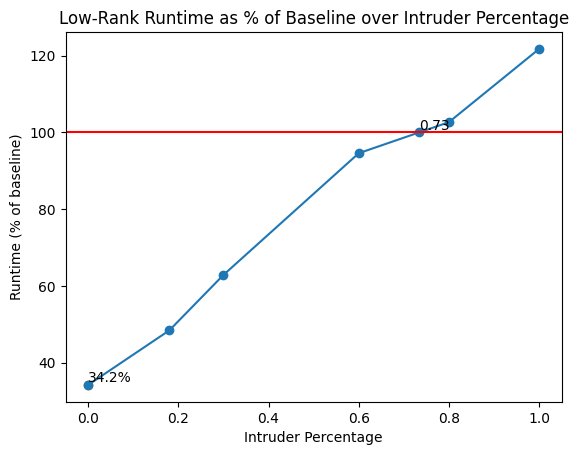

In [4]:
import matplotlib.pyplot as plt

# data copied from Mac terminal outputs
full_svd_sec = 726.36
lowrank_per = [0., 0.18, 0.3, 0.6, 0.8, 1.0]
lowrank_sec = [248.13, 351.45, 456.43, 686.86, 745.69, 884.35]
lowrank_percent = [(sec / full_svd_sec) * 100 for sec in lowrank_sec]

plt.figure()
plt.plot(lowrank_per, lowrank_percent, marker='o')

# baseline
plt.axhline(y=100, color='red')

# intersection with y=100
for i in range(len(lowrank_percent) - 1):
    y1, y2 = lowrank_percent[i], lowrank_percent[i+1]
    if (y1 - 100) * (y2 - 100) <= 0:  # crossing
        x1, x2 = lowrank_per[i], lowrank_per[i+1]
        x_cross = x1 + (100 - y1) * (x2 - x1) / (y2 - y1)
        plt.scatter(x_cross, 100)
        plt.text(x_cross, 100, f"{x_cross:.2f}", ha='left', va='bottom')

# y-axis intersection
y0 = lowrank_percent[0]
plt.scatter(0, y0)
plt.text(0, y0, f"{y0:.1f}%", ha='left', va='bottom')

plt.xlabel("Intruder Percentage")
plt.ylabel("Runtime (% of baseline)")
plt.title("Low-Rank Runtime as % of Baseline over Intruder Percentage")
plt.show()

----------------
----------------

### Not really relevant, just documented

Tests with lowrank approach in colab to compare gain on CPU with GPU.

lowrank found for the given fine-tuned layers 18% intruders, 2% were false positives

**CPU**

In [ ]:
from peft import PeftModel
from utils.intruders_lowrank import reduce_intruder_dimension
from transformers import LlavaForConditionalGeneration
from transformers.trainer_utils import get_last_checkpoint
import torch
from torch.utils.benchmark import Timer
import os
import json
import time

last_checkpoint = get_last_checkpoint("llava-emotion-lora")

logs_path = os.path.join(last_checkpoint, "trainer_state.json")
with open(logs_path, "r") as f:
    check_data = json.load(f)
log_history = check_data["log_history"]

base_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
tuned_model = PeftModel.from_pretrained(base_model, check_data["best_model_checkpoint"])


lowrank_svd = Timer(
    stmt="reduce_intruder_dimension(tuned_model)",
    globals={"tuned_model":tuned_model,
             "reduce_intruder_dimension": reduce_intruder_dimension})

full_svd = Timer(
    stmt="reduce_intruder_dimension(tuned_model,use_lowrank=False)",
    globals={"tuned_model":tuned_model,
             "reduce_intruder_dimension": reduce_intruder_dimension})


print(full_svd.blocked_autorange())
print(lowrank_svd.blocked_autorange())


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

Restart kernel

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

**GPU**

In [ ]:
from peft import PeftModel
from utils.intruders_lowrank import reduce_intruder_dimension
from transformers import LlavaForConditionalGeneration
from transformers.trainer_utils import get_last_checkpoint
import torch
from torch.utils.benchmark import Timer
import os
import json
import time

device = torch.device("cuda")

last_checkpoint = get_last_checkpoint("llava-emotion-lora")

logs_path = os.path.join(last_checkpoint, "trainer_state.json")
with open(logs_path, "r") as f:
    check_data = json.load(f)
log_history = check_data["log_history"]

base_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(device)

tuned_model = PeftModel.from_pretrained(base_model, check_data["best_model_checkpoint"])


lowrank_svd = Timer(
    stmt="reduce_intruder_dimension(tuned_model)",
    globals={"tuned_model":tuned_model,
             "reduce_intruder_dimension": reduce_intruder_dimension})

full_svd = Timer(
    stmt="reduce_intruder_dimension(tuned_model,use_lowrank=False)",
    globals={"tuned_model":tuned_model,
             "reduce_intruder_dimension": reduce_intruder_dimension})


print(full_svd.blocked_autorange())
print(lowrank_svd.blocked_autorange())

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: No intruders
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 1
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: No intruders
base_model.model.model.vision_

Restart kernel

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

--------------------
--------------------

## Abandonned - cudaMemcpyAsync approach

Trying to reduce cudaMemcpyAsync overhead when run via GPU by keeping intruders indices as tensor instead of list - scraped only 3% of.

In [ ]:
from peft import PeftModel
from transformers import LlavaForConditionalGeneration
from transformers.trainer_utils import get_last_checkpoint
from utils.intruders_cudaMemcpyAsync import reduce_intruder_dimension
import torch
import os
import json

last_checkpoint = get_last_checkpoint("llava-emotion-lora")
logs_path = os.path.join(last_checkpoint, "trainer_state.json")
with open(logs_path, "r") as f:
    check_data = json.load(f)
log_history = check_data["log_history"]

device = torch.device("cuda")

base_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(device)

tuned_model = PeftModel.from_pretrained(base_model, check_data["best_model_checkpoint"])


# subset of layers because colab ran out of RAM
original_named_modules = tuned_model.named_modules
counter = 0
max_layers = 500

def limited_named_modules():
    global counter
    for name, module in original_named_modules():
        yield name, module
        counter += 1
        if counter >= max_layers:
            return

tuned_model.named_modules = limited_named_modules

# warm up run (to get rid of module/kernel loading overhead)
with torch.no_grad():
    counter = 0
    reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)

torch.cuda.synchronize()

# actual profiling run
counter = 0

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CUDA,
        torch.profiler.ProfilerActivity.CPU,
    ],
    record_shapes=True,
    with_stack=False
) as prof:
    torch.cuda.synchronize()
    reduce_intruder_dimension(tuned_model, threshold_epsilon=0.7)
    torch.cuda.synchronize()


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 630
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 842
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 761
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: Intruders: 860
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 738
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: Intruders: 796
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 812
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: Intruders: 718
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 726
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: Intruders: 688
base_model

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj: Intruders: 630
base_model.model.model.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj: Intruders: 842
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.v_proj: Intruders: 761
base_model.model.model.vision_tower.vision_model.encoder.layers.1.self_attn.q_proj: Intruders: 860
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj: Intruders: 738
base_model.model.model.vision_tower.vision_model.encoder.layers.2.self_attn.q_proj: Intruders: 796
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.v_proj: Intruders: 812
base_model.model.model.vision_tower.vision_model.encoder.layers.3.self_attn.q_proj: Intruders: 718
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.v_proj: Intruders: 726
base_model.model.model.vision_tower.vision_model.encoder.layers.4.self_attn.q_proj: Intruders: 688
base_model

In [ ]:
from IPython.display import display, Markdown

table = prof.key_averages().table(sort_by="cuda_time_total")
display(Markdown(f"```\n{table}\n```"))

```
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       aten::linalg_svd         0.00%     483.522us        99.01%       20.219s     259.222ms       0.000us         0.00%       30.906s     396.232ms            78  
                                      aten::_linalg_svd         1.91%     390.140ms        99.01%       20.219s     259.215ms       18.168s        99.63%       30.906s     396.232ms            78  
void svd_column_rotate_batch<float, 5, 3>(long, int ...         0.00%       0.000us         0.00%       0.000us       0.000us        8.931s        48.97%        8.931s      47.666us        187362  
                                           Buffer Flush         0.34%      68.706ms         0.34%      68.755ms       1.964ms        8.716s        47.80%        8.716s     249.037ms            35  
void gesvdbj_batch_32x16<float, float>(long, int con...         0.00%       0.000us         0.00%       0.000us       0.000us        5.178s        28.40%        5.178s      55.276us         93681  
                                Activity Buffer Request         0.72%     146.292ms         0.72%     146.292ms       4.572ms        4.016s        22.02%        4.016s     125.505ms            32  
void svd_row_rotate_batch_32x16<float>(long, int con...         0.00%       0.000us         0.00%       0.000us       0.000us        3.953s        21.68%        3.953s      42.193us         93681  
                                       cudaLaunchKernel        13.15%        2.685s        13.57%        2.771s       7.053us       0.000us         0.00%     468.781ms       1.193us        392846  
                                        cudaMemcpyAsync        82.22%       16.789s        82.33%       16.812s       6.478ms       0.000us         0.00%     348.285ms     134.214us          2595  
void offA_stage1<float, float, 5, 3>(long, long, flo...         0.00%       0.000us         0.00%       0.000us       0.000us      46.403ms         0.25%      46.403ms      29.650us          1565  
                                           aten::matmul         0.00%     916.143us         0.09%      18.456ms     101.407us       0.000us         0.00%      43.413ms     238.536us           182  
                                               aten::mm         0.07%      13.959ms         0.09%      17.540ms      96.373us      43.413ms         0.24%      43.413ms     238.536us           182  
                                  volta_sgemm_128x64_nn         0.00%       0.000us         0.00%       0.000us       0.000us      29.436ms         0.16%      29.436ms     377.382us            78  
                                  volta_sgemm_128x64_tn         0.00%       0.000us         0.00%       0.000us       0.000us      13.201ms         0.07%      13.201ms     507.743us            26  
                                            aten::copy_         0.17%      34.802ms         0.38%      77.702ms      56.966us       9.058ms         0.05%      10.510ms       7.705us          1364  
void colperm_kernel<float, float, 5, 4>(long, long, ...         0.00%       0.000us         0.00%       0.000us       0.000us       7.412ms         0.04%       7.412ms      47.515us           156  
void pegasus_sortI32_by_key_local_core<256, 4, false...         0.00%       0.000us         0.00%       0.000us       0.000us       6.594ms         0.04%       6.594ms       2.727us          2418  
void pegasus_sortI32_by_key_merge_core<256, 4>(int, ...         0.00%       0.000us         0.00%       0.000us       0.000us       6.528ms         0.04%       6.528ms       2.700us          2418  
void pegasusIinclusive_scan_domino_v1_core<256, 4>(i...         0.00%       0.000us         0.00%       0.000us       0.000us       6.504ms         0.04%       6.504ms       2.606us          2496  
void pegasusIinclusive_localscan_core<256, 4>(int, i...         0.00%       0.000us         0.00%       0.000us       0.000us       5.667ms         0.03%       5.667ms       2.270us          2496  
void at::native::elementwise_kernel<128, 2, at::nati...         0.00%       0.000us         0.00%       0.000us       0.000us       4.939ms         0.03%       4.939ms      27.140us           182  
                                            aten::clone         0.01%       2.651ms         0.03%       5.488ms      70.365us       0.000us         0.00%       4.640ms      59.492us            78  
void pegasusIinclusive_scan_merge_core<256, 4>(int, ...         0.00%       0.000us         0.00%       0.000us       0.000us       4.284ms         0.02%       4.284ms       1.716us          2496  
                                               aten::to         0.01%       2.469ms         0.47%      95.970ms     109.056us       0.000us         0.00%       3.994ms       4.539us           880  
                                         aten::_to_copy         0.12%      24.641ms         0.46%      93.500ms     106.250us       0.000us         0.00%       3.994ms       4.539us           880  
                                            aten::index         0.02%       4.246ms         0.03%       6.653ms      63.967us       3.633ms         0.02%       3.633ms      34.935us           104  
            void offA_stage2<float, 5, 3>(long, float*)         0.00%       0.000us         0.00%       0.000us       0.000us       3.470ms         0.02%       3.470ms       2.217us          1565  
                                        Memset (Device)         0.00%       0.000us         0.00%       0.000us       0.000us       3.463ms         0.02%       3.463ms       0.659us          5252  
void batch_FnrmA_stage1<float, float, 8>(long, long,...         0.00%       0.000us         0.00%       0.000us       0.000us       3.124ms         0.02%       3.124ms      40.045us            78  
void batch_eye_kernel<float, 5, 3>(long, long, float...         0.00%       0.000us         0.00%       0.000us       0.000us       3.089ms         0.02%       3.089ms      19.804us           156  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       2.772ms         0.02%       2.772ms      53.300us            52  
void syevj_parallel_order_set_kernel<512>(long, int*...         0.00%       0.000us         0.00%       0.000us       0.000us       2.683ms         0.01%       2.683ms      17.196us           156  
                                              aten::add         0.01%       1.134ms         0.01%       1.742ms      33.508us       2.670ms         0.01%       2.670ms      51.345us            52  
                       Memcpy DtoH (Device -> Pageable)         0.00%       0.000us         0.00%       0.000us       0.000us       2.520ms         0.01%       2.520ms       1.401us          1799  
void svd_col_scale_kernel<float, 256>(long, long, fl...         0.00%       0.000us         0.00%       0.000us       0.000us       2.447ms         0.01%       2.447ms      31.369us            78  
void at::native::index_elementwise_kernel<128, 4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       2.376ms         0.01%       2.376ms      45.689us            52  
                                              aten::mul         0.01%       1.431ms         0.03%       6.085ms     117.011us       1.816ms         0.01%       1.816ms      34.933us            52  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       1.816ms         0.01%       1.816ms      34.933us            52  
                                              aten::abs         0.01%       2.418ms         0.03%       5.310ms     102.109us     896.072us         0.00%       1.792ms      34.464us            52  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us       1.538ms         0.01%       1.538ms       6.151us           250  
                       Memcpy HtoD (Pageable -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us       1.452ms         0.01%       1.452ms       6.484us           224  
                                              aten::sub         0.00%     437.640us         0.00%     626.299us      24.088us       1.379ms         0.01%       1.379ms      53.043us            26  
                                             aten::diag         0.01%       1.337ms         0.07%      15.115ms     145.341us       0.000us         0.00%       1.357ms      13.050us           104  
                                       aten::diag_embed         0.01%       2.156ms         0.07%      13.778ms     132.482us       0.000us         0.00%       1.357ms      13.050us           104  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us       1.277ms         0.01%       1.277ms      49.135us            26  
void at::native::vectorized_gather_kernel<16, long>(...         0.00%       0.000us         0.00%       0.000us       0.000us       1.257ms         0.01%       1.257ms      24.181us            52  
                                            aten::zero_         0.01%       1.592ms         0.03%       7.044ms      23.960us       0.000us         0.00%       1.200ms       4.083us           294  
                                            aten::fill_         0.01%       2.838ms         0.03%       5.452ms      22.163us       1.200ms         0.01%       1.200ms       4.880us           246  
                                            aten::zeros         0.01%       1.403ms         0.06%      11.550ms      63.463us       0.000us         0.00%       1.200ms       6.596us           182  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       1.058ms         0.01%       1.058ms      10.174us           104  
void lascl_kernel<float, float, 8>(long, long, float...         0.00%       0.000us         0.00%       0.000us       0.000us       1.002ms         0.01%       1.002ms      12.852us            78  
                                             aten::sqrt         0.01%       1.840ms         0.01%       2.912ms      28.002us     908.069us         0.00%     908.069us       8.731us           104  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     908.069us         0.00%     908.069us       8.731us           104  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     896.072us         0.00%     896.072us      34.464us            26  
                                             aten::div_         0.06%      12.536ms         0.06%      12.888ms     495.699us     798.508us         0.00%     798.508us      30.712us            26  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     798.508us         0.00%     798.508us      30.712us            26  
                         Memcpy DtoD (Device -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us     744.580us         0.00%     744.580us       1.591us           468  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     689.582us         0.00%     689.582us      26.522us            26  
                                  volta_sgemm_128x32_nn         0.00%       0.000us         0.00%       0.000us       0.000us     531.857us         0.00%     531.857us      20.456us            26  
                                              aten::max         0.01%       1.197ms         0.01%       1.595ms      61.349us     501.232us         0.00%     501.232us      19.278us            26  
void at::native::reduce_kernel<512, 1, at::native::R...         0.00%       0.000us         0.00%       0.000us       0.000us     501.232us         0.00%     501.232us      19.278us            26  
                             aten::_linalg_check_errors         0.06%      12.901ms         0.47%      94.994ms       1.218ms       0.000us         0.00%     438.673us       5.624us            78  
void batch_FnrmA_stage2<float, 8>(long, float*, long...         0.00%       0.000us         0.00%       0.000us       0.000us     362.672us         0.00%     362.672us       4.650us            78  
                                              aten::any         0.02%       3.100ms         0.09%      18.747ms     240.341us       0.000us         0.00%     327.890us       4.204us            78  
                                            aten::where         0.00%     120.592us         0.06%      12.769ms     491.117us       0.000us         0.00%     275.996us      10.615us            26  
                                    aten::nonzero_numpy         0.00%     193.681us         0.06%      12.648ms     486.479us       0.000us         0.00%     275.996us      10.615us            26  
                                          aten::nonzero         0.02%       3.511ms         0.06%      11.962ms     460.065us     275.996us         0.00%     275.996us      10.615us            26  
void pegasus_sortsign_by_key_local_core<float, 256, ...         0.00%       0.000us         0.00%       0.000us       0.000us     267.032us         0.00%     267.032us       3.423us            78  
void pegasus_sortsign_by_key_merge_core<float, 256, ...         0.00%       0.000us         0.00%       0.000us       0.000us     209.783us         0.00%     209.783us       2.690us            78  
void at::native::unrolled_elementwise_kernel<at::nat...         0.00%       0.000us         0.00%       0.000us       0.000us     203.672us         0.00%     203.672us       2.611us            78  
void scal_kernel_val<float, float>(cublasScalParamsV...         0.00%       0.000us         0.00%       0.000us       0.000us     193.756us         0.00%     193.756us       2.484us            78  
void gesvdj_diagonal_kernel<float, float, 256>(long,...         0.00%       0.000us         0.00%       0.000us       0.000us     179.451us         0.00%     179.451us       2.301us            78  
                         Memcpy DtoH (Device -> Pinned)         0.00%       0.000us         0.00%       0.000us       0.000us     149.918us         0.00%     149.918us       1.442us           104  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     142.269us         0.00%     142.269us       1.824us            78  
                            copy_info_kernel(int, int*)         0.00%       0.000us         0.00%       0.000us       0.000us     140.317us         0.00%     140.317us       1.799us            78  
                void pegasus_set_identy<128>(int, int*)         0.00%       0.000us         0.00%       0.000us       0.000us     123.518us         0.00%     123.518us       1.584us            78  
                                             aten::item         0.00%     421.828us         0.31%      63.346ms     812.133us       0.000us         0.00%     110.783us       1.420us            78  
                              aten::_local_scalar_dense         0.15%      31.547ms         0.31%      62.925ms     806.725us     110.783us         0.00%     110.783us       1.420us            78  
void at_cuda_detail::cub::DeviceSelectSweepKernel<at...         0.00%       0.000us         0.00%       0.000us       0.000us     105.567us         0.00%     105.567us       4.060us            26  
                                  volta_sgemm_128x32_nt         0.00%       0.000us         0.00%       0.000us       0.000us      99.517us         0.00%      99.517us       3.828us            26  
void at_cuda_detail::cub::DeviceReduceSingleTileKern...         0.00%       0.000us         0.00%       0.000us       0.000us      90.942us         0.00%      90.942us       3.498us            26  
void gemmSN_NN_kernel<float, 128, 2, 4, 8, 4, 4, fal...         0.00%       0.000us         0.00%       0.000us       0.000us      75.839us         0.00%      75.839us       2.917us            26  
                                               aten::lt         0.04%       8.882ms         0.05%       9.190ms     353.446us      64.416us         0.00%      64.416us       2.478us            26  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us      64.416us         0.00%      64.416us       2.478us            26  
void at_cuda_detail::cub::DeviceCompactInitKernel<at...         0.00%       0.000us         0.00%       0.000us       0.000us      40.352us         0.00%      40.352us       1.552us            26  
                                  cudaDeviceSynchronize         0.00%      73.404us         0.00%      73.404us      24.468us       0.000us         0.00%       0.000us       0.000us             3  
                                            aten::empty         0.04%       7.500ms         0.04%       7.500ms      14.706us       0.000us         0.00%       0.000us       0.000us           510  
                                           aten::detach         0.00%     434.146us         0.00%       1.021ms       4.557us       0.000us         0.00%       0.000us       0.000us           224  
                                                 detach         0.00%     586.569us         0.00%     586.569us       2.619us       0.000us         0.00%       0.000us       0.000us           224  
                                         aten::uniform_         0.24%      49.380ms         0.24%      49.380ms     146.965us       0.000us         0.00%       0.000us       0.000us           336  
                                    aten::empty_strided         0.04%       8.143ms         0.05%       9.281ms      10.546us       0.000us         0.00%       0.000us       0.000us           880  
                                        aten::expand_as         0.00%     619.365us         0.01%       1.658ms       7.404us       0.000us         0.00%       0.000us       0.000us           224  
                                           aten::expand         0.00%     676.239us         0.01%       1.039ms       4.639us       0.000us         0.00%       0.000us       0.000us           224  
                                       aten::as_strided         0.01%       1.497ms         0.01%       1.497ms       1.821us       0.000us         0.00%       0.000us       0.000us           822  
                                  cudaStreamSynchronize         0.20%      41.306ms         0.20%      41.306ms      19.420us       0.000us         0.00%       0.000us       0.000us          2127  
                aten::_has_compatible_shallow_copy_type         0.00%     350.118us         0.00%     350.118us       0.484us       0.000us         0.00%       0.000us       0.000us           724  
                                  cudaStreamIsCapturing         0.00%      14.283us         0.00%      14.283us       2.857us       0.000us         0.00%       0.000us       0.000us             5  
                                             cudaMalloc         0.01%       1.123ms         0.01%       1.123ms     224.599us       0.000us         0.00%       0.000us       0.000us             5  
          cudaOccupancyMaxActiveBlocksPerMultiprocessor         0.00%     425.619us         0.00%     425.619us       3.274us       0.000us         0.00%       0.000us       0.000us           130  
                                               aten::mT         0.00%     470.363us         0.01%       1.399ms       8.970us       0.000us         0.00%       0.000us       0.000us           156  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 20.421s
Self CUDA time total: 18.236s

```